In [1]:
import altitude_helper
from altitude_helper import *
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)

# for interpolation
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation


In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


In [3]:
## Get the projected latitude and longitude 

h_target = 110000 

lat_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

full_yknf_lat110 = np.array(yknf_rgb_asi_ds.lat_110)
full_yknf_lon110 = np.array(yknf_rgb_asi_ds.lon_110)
yknf_110_mask = np.isnan(full_yknf_lat110) | np.isnan(full_yknf_lon110) # apply this mask to all frames across all elevations for YKNF


print(full_yknf_lat110.shape)

lat_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

full_fsmi_lat110 = np.array(fsmi_rgb_asi_ds.lat_110)
full_fsmi_lon110 = np.array(fsmi_rgb_asi_ds.lon_110)
fsmi_110_mask = np.isnan(full_fsmi_lat110) | np.isnan(full_fsmi_lon110) # apply this mask to all frames across all elevations for YKNF


yknf_lat_110_proj, yknf_lon_110_proj = project_lat_lon(full_azimuth_yknf, 
                                                     full_elevation_yknf, 
                                                     lat_yknf, 
                                                     lon_yknf, 
                                                     h_target, 
                                                     yknf_110_mask)

fsmi_lat_110_proj, fsmi_lon_110_proj = project_lat_lon(full_azimuth_fsmi, 
                                                     full_elevation_fsmi, 
                                                     lat_fsmi, 
                                                     lon_fsmi, 
                                                     h_target, 
                                                     fsmi_110_mask)


(480, 553)


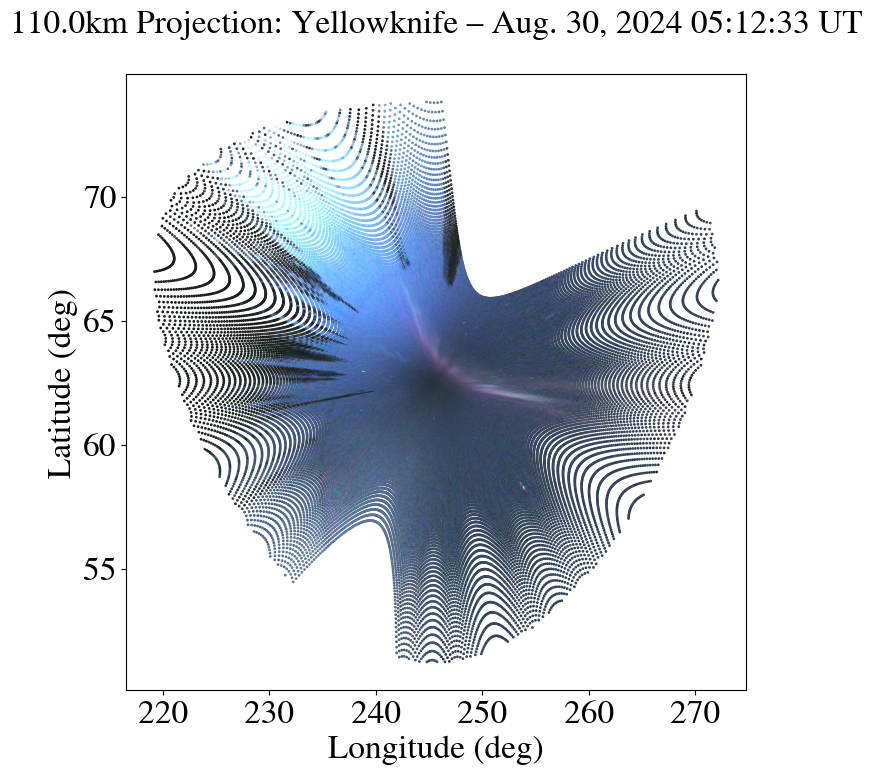

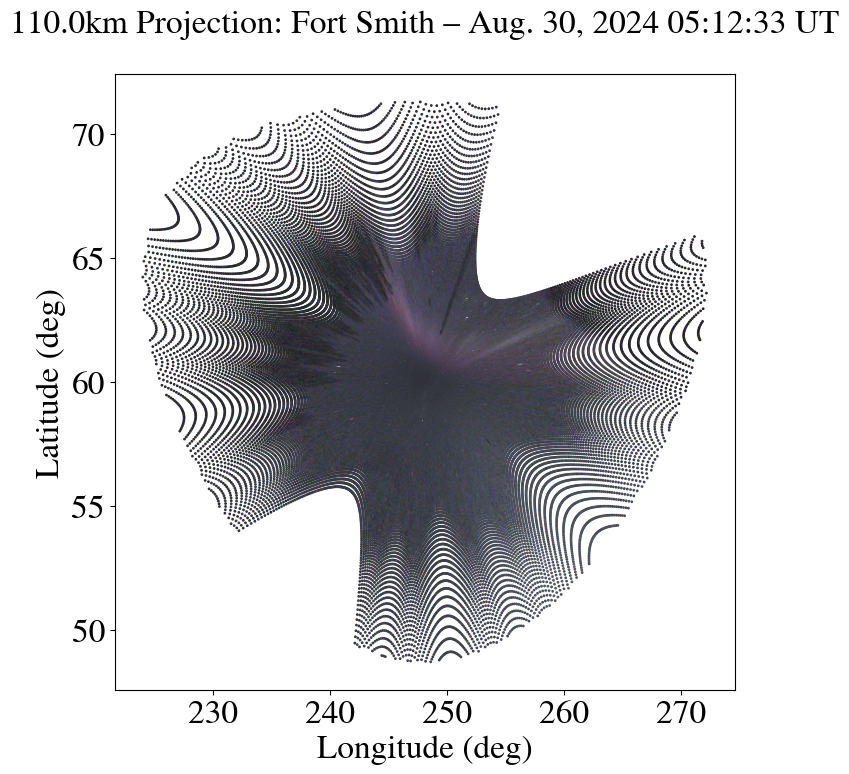

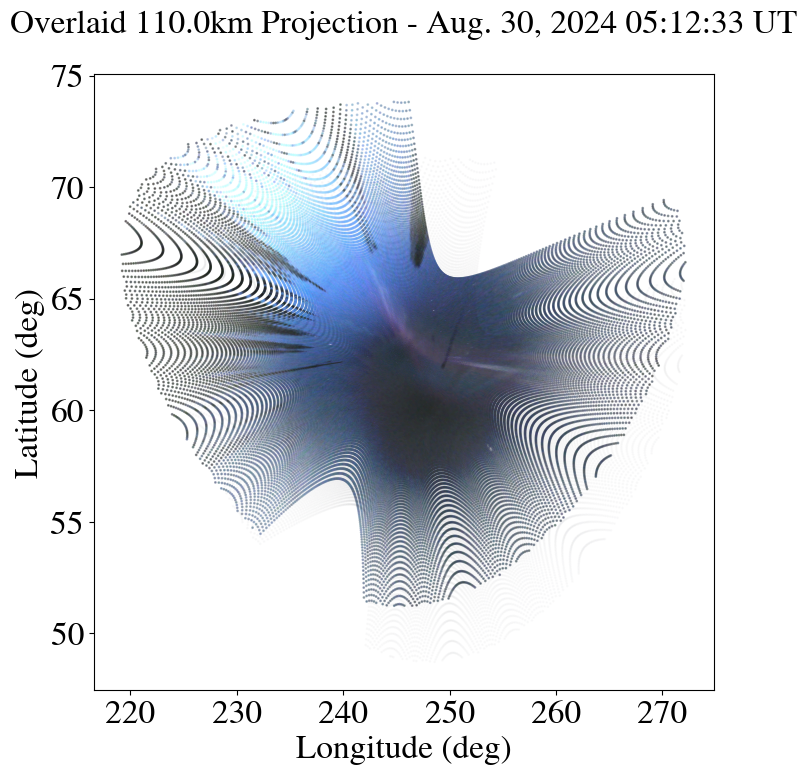

In [4]:
## Plot the projected latitude and longitude

time_index = 251 # 5:10 UTC
site_name_yknf = "Yellowknife" 
site_name_fsmi = "Fort Smith" 

yknf_rgb, fsmi_rgb = plot_lat_lon(yknf_rgb_asi_ds, 
                                 fsmi_rgb_asi_ds, 
                                 time_index, 
                                 site_name_yknf, 
                                 site_name_fsmi, 
                                 yknf_lat_110_proj, 
                                 yknf_lon_110_proj, 
                                 fsmi_lat_110_proj, 
                                 fsmi_lon_110_proj,
                                 h_target)

## Interpolation (Linear)
1. define a common grid over which to perform the interpolation --> this common grid is based on the maximum and minimum latitude/longitude BEFORE masking
- get the overlapping area
3. interpolate the pixel intensities from both cameras over this entire grid
4. manually cut out the area with the auroral pixels (create some custom mask for a particular altitude, then repeat for many altitudes to get a correlation plot over different projected altitudes)

DON'T DO MASKING --> want to independently pick out some of the 

In [5]:
yknf_rgb.shape

(480, 553, 3)

In [6]:
yknf_lat_110_proj.shape

(480, 553)

In [7]:
def rgb_interpolate(lat_proj, lon_proj, rgb, 
                    grid_x, grid_y,
                   lat_min, lat_max, lon_min, lon_max):
    """
    input:
        lat_proj = 2D projected latitude arr (output of project_lat_lon())
        lon_proj = 2D projected longitude arr (output of project_lat_lon())
        rgb = 3D rgb array (output of plot_lat_lon()) 
        n_lat = how many x-values for interpolated grid
        n_lon = how many y-values for interpolated grid 
        lat_min = minimum latitude to create grid for (should be common between the 2 cameras)
        lat_max = maximum latitude to create grid for (should be common between the 2 cameras)
        lon_min = minimum longitude to create grid for (should be common between the 2 cameras)
        lon_max = maximum longitude to create grid for (should be common between the 2 cameras)

    output:
        interp_intensity_R = 2D arr (grid_x, grid_y) of interpolated R-channel 
        interp_intensity_G = 2D arr (grid_x, grid_y) of interpolated G-channel 
        interp_intensity_B = 2D arr (grid_x, grid_y) of interpolated B-channel 
    """
    # grid --> need to make this more sophisticated, bc some distortion from using the dims of az/el grid
    lat_grid = np.linspace(lat_min, lat_max, n_lat)
    lon_grid = np.linspace(lon_min, lon_max, n_lon)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
    
    # separate into R, G, B channels
    R = rgb[:,:, 0]
    G = rgb[:,:, 1]
    B = rgb[:,:, 2]

    # flatten yknf and fsmi projected arrays + R + G + B arrays 
    flattened_points = np.column_stack((lon_proj.flatten(), lat_proj.flatten())) # (N,2) pairs of (lat, lon)
    flattened_R = R.flatten()
    flattened_G = G.flatten()
    flattened_B = B.flatten()
    

    # remove NaNs
    # masks for NaNs in R, G, and B channels separately 
    nan_mask_R = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_R))
    nan_mask_G = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_G))
    nan_mask_B = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_B))
    
    points_R_clean = flattened_points[nan_mask_R]
    points_G_clean = flattened_points[nan_mask_G]
    points_B_clean = flattened_points[nan_mask_B]
    
    values_R_clean = flattened_R[nan_mask_R]
    values_G_clean = flattened_G[nan_mask_G]
    values_B_clean = flattened_B[nan_mask_B]
    
    
    # interpolation 
    interp_intensity_R = griddata(points_R_clean, values_R_clean, (lon_mesh, lat_mesh), method='linear')
    interp_intensity_G = griddata(points_G_clean, values_G_clean, (lon_mesh, lat_mesh), method='linear')
    interp_intensity_B = griddata(points_B_clean, values_B_clean, (lon_mesh, lat_mesh), method='linear')

    return interp_intensity_R, interp_intensity_G, interp_intensity_B

    
    

In [8]:
lat_min = min(np.nanmin(yknf_lat_110_proj), np.nanmin(fsmi_lat_110_proj))
lon_min = min(np.nanmin(yknf_lon_110_proj), np.nanmin(fsmi_lon_110_proj))
lat_max = max(np.nanmax(yknf_lat_110_proj), np.nanmax(fsmi_lat_110_proj))
lon_max = max(np.nanmax(yknf_lon_110_proj), np.nanmax(fsmi_lon_110_proj))

n_lat = 500
n_lon = 500

yknf_interp_intensity_R, yknf_interp_intensity_G, yknf_interp_intensity_B = rgb_interpolate(yknf_lat_110_proj, yknf_lon_110_proj, yknf_rgb, 
                                                                                            n_lat, n_lon,
                                                                                            lat_min, lat_max, lon_min, lon_max)

fsmi_interp_intensity_R, fsmi_interp_intensity_G, fsmi_interp_intensity_B = rgb_interpolate(fsmi_lat_110_proj, fsmi_lon_110_proj, fsmi_rgb, 
                                                                                            n_lat, n_lon,
                                                                                            lat_min, lat_max, lon_min, lon_max)


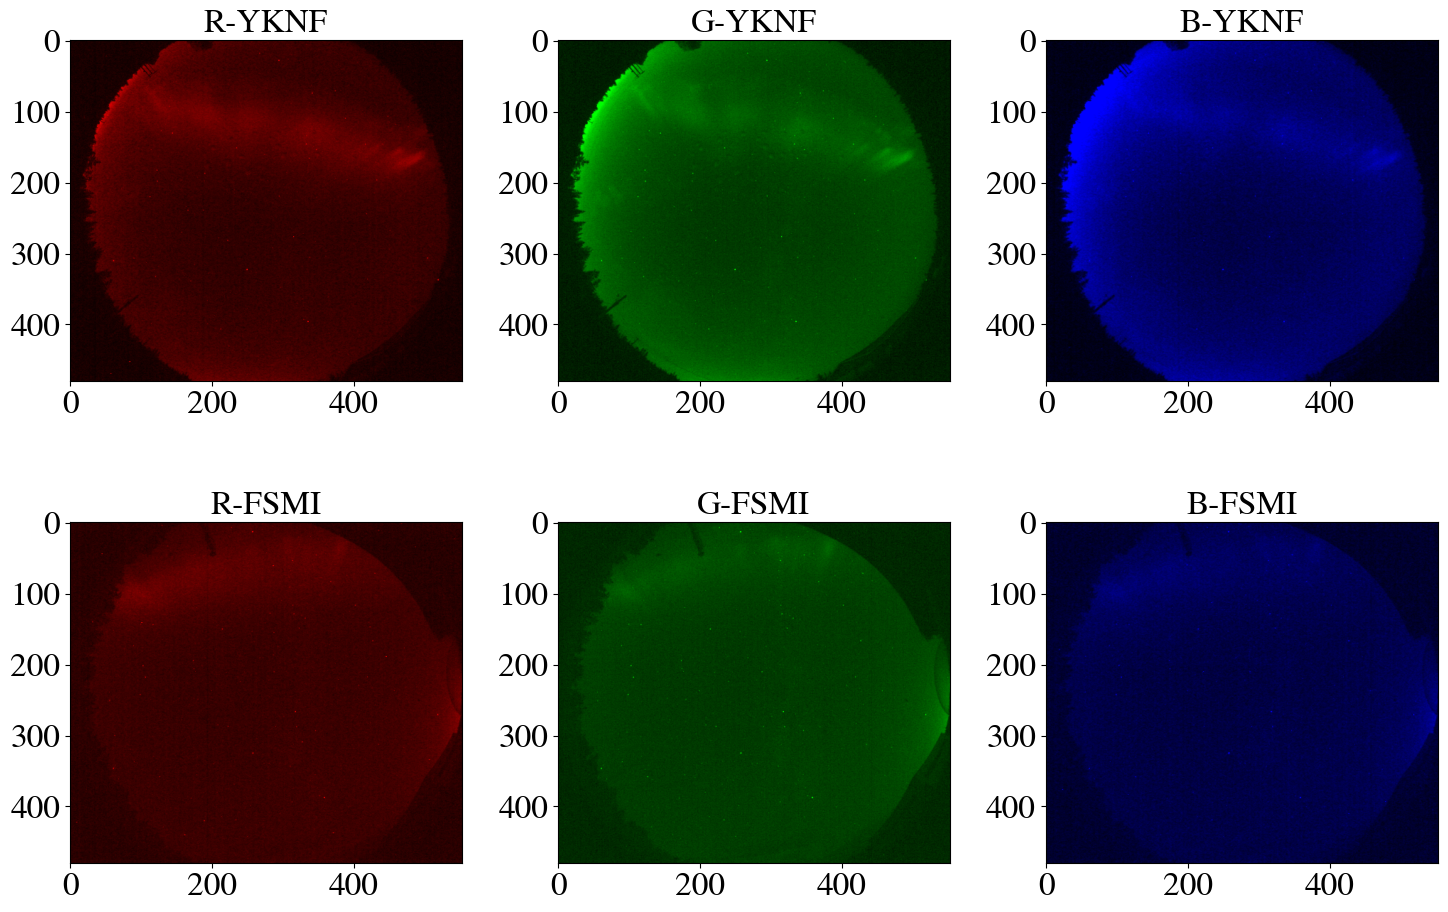

In [9]:
## YKNF vs FSMI: Plot original camera separate R, G, B channels 

R_yknf = yknf_rgb[:,:, 0]
G_yknf = yknf_rgb[:,:, 1]
B_yknf = yknf_rgb[:,:, 2]

R_fsmi = fsmi_rgb[:,:, 0]
G_fsmi = fsmi_rgb[:,:, 1]
B_fsmi = fsmi_rgb[:,:, 2]

R_color_yknf = np.dstack((R_yknf / 255.0, np.zeros_like(R_yknf), np.zeros_like(R_yknf))) 
G_color_yknf = np.dstack((np.zeros_like(G_yknf), G_yknf / 255.0, np.zeros_like(G_yknf)))
B_color_yknf = np.dstack((np.zeros_like(B_yknf), np.zeros_like(B_yknf), B_yknf / 255.0))

R_color_fsmi = np.dstack((R_fsmi / 255.0, np.zeros_like(R_fsmi), np.zeros_like(R_fsmi))) 
G_color_fsmi = np.dstack((np.zeros_like(G_fsmi), G_fsmi / 255.0, np.zeros_like(G_fsmi)))
B_color_fsmi = np.dstack((np.zeros_like(B_fsmi), np.zeros_like(B_fsmi), B_fsmi / 255.0))


fig, axes = plt.subplots(2, 3, figsize=(15,10))
all_images = [R_color_yknf, G_color_yknf, B_color_yknf, R_color_fsmi, G_color_fsmi, B_color_fsmi]
all_titles = ['R-YKNF', 'G-YKNF', 'B-YKNF', 'R-FSMI', 'G-FSMI', 'B-FSMI']

for ax, img, title in zip(axes.flat, all_images, all_titles):
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(title)
    
plt.tight_layout()
plt.show()

/home/molidae/miniconda3/envs/co38/lib/python3.8/site-packages/matplotlib/cm.py:496: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


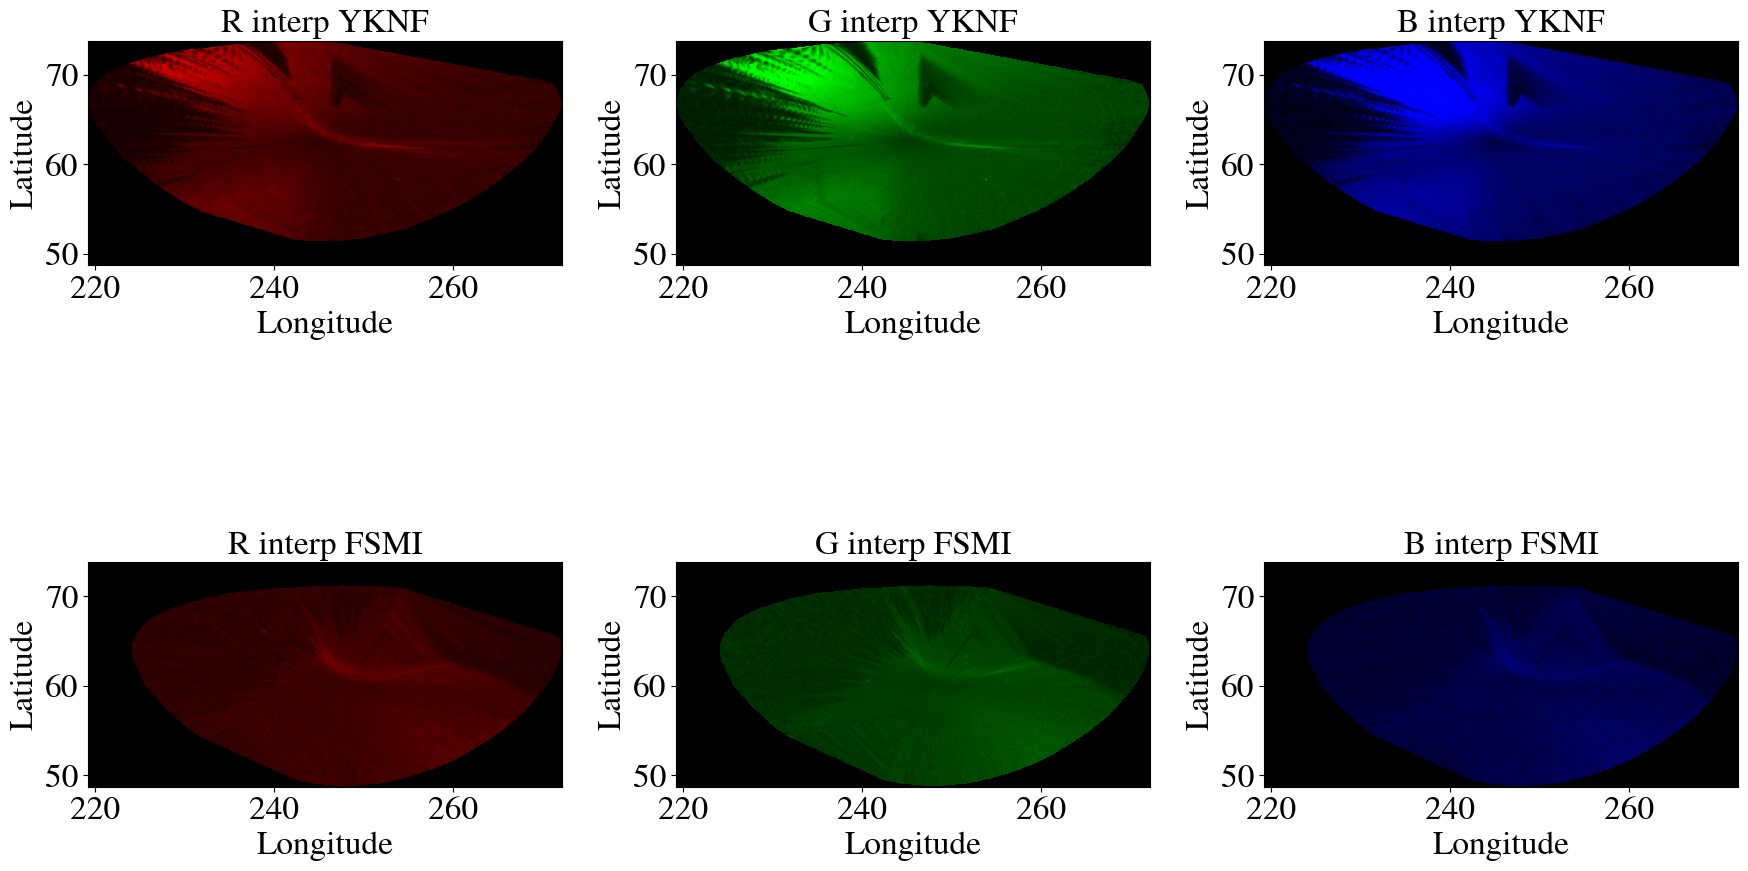

In [10]:
## YKNF vs FSMI: Plot interpolated R, G, B channels

yknf_R_interp_color = np.dstack((yknf_interp_intensity_R / 255.0, np.zeros_like(yknf_interp_intensity_R), np.zeros_like(yknf_interp_intensity_R))) 
yknf_G_interp_color = np.dstack((np.zeros_like(yknf_interp_intensity_G), yknf_interp_intensity_G / 255.0, np.zeros_like(yknf_interp_intensity_G)))
yknf_B_interp_color = np.dstack((np.zeros_like(yknf_interp_intensity_B), np.zeros_like(yknf_interp_intensity_B), yknf_interp_intensity_B / 255.0))

fsmi_R_interp_color = np.dstack((fsmi_interp_intensity_R / 255.0, np.zeros_like(fsmi_interp_intensity_R), np.zeros_like(fsmi_interp_intensity_R))) 
fsmi_G_interp_color = np.dstack((np.zeros_like(fsmi_interp_intensity_G), fsmi_interp_intensity_G / 255.0, np.zeros_like(fsmi_interp_intensity_G)))
fsmi_B_interp_color = np.dstack((np.zeros_like(fsmi_interp_intensity_B), np.zeros_like(fsmi_interp_intensity_B), fsmi_interp_intensity_B / 255.0))


fig, axes = plt.subplots(2, 3, figsize=(18,12))
all_images = [yknf_R_interp_color, yknf_G_interp_color, yknf_B_interp_color, fsmi_R_interp_color, fsmi_G_interp_color, fsmi_B_interp_color]
all_titles = ['R interp YKNF', 'G interp YKNF', 'B interp YKNF', 'R interp FSMI', 'G interp FSMI', 'B interp FSMI']

for ax, img, title in zip(axes.flat, all_images, all_titles):
    ax.imshow(np.clip(img, 0, 1),
             origin='lower',
             extent=[lon_min, lon_max, lat_min, lat_max])  # clip to stay in valid display range
    ax.set_title(title)
    ax.set_aspect('equal')  # keeps proportions
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

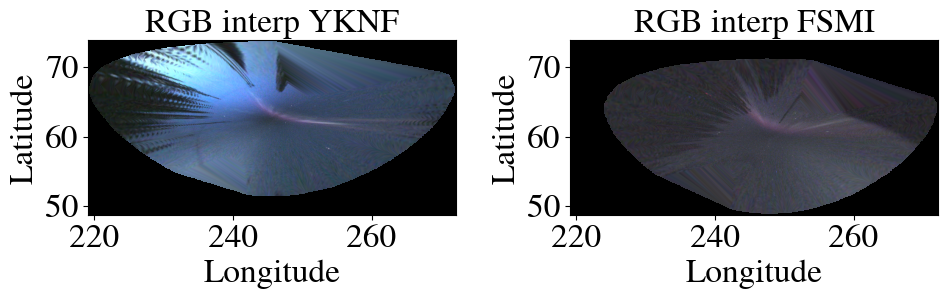

In [11]:
## YKNF vs FSMI: Plot interpolated stacked RGB

yknf_rgb_image = np.dstack((yknf_interp_intensity_R/255.0, yknf_interp_intensity_G/255.0, yknf_interp_intensity_B/255.0))
fsmi_rgb_image = np.dstack((fsmi_interp_intensity_R/255.0, fsmi_interp_intensity_G/255.0, fsmi_interp_intensity_B/255.0))


fig, axes = plt.subplots(1, 2, figsize=(10,20))
all_images = [yknf_rgb_image, fsmi_rgb_image]
all_titles = ['RGB interp YKNF', 'RGB interp FSMI']

for ax, img, title in zip(axes.flat, all_images, all_titles):
    ax.imshow(np.clip(img, 0, 1),
             origin='lower',
             extent=[lon_min, lon_max, lat_min, lat_max]) 
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()


In [12]:
## strict line cut offs to isolate auroras

## (234, 65), (245, 70) --> y-70 = 0.4545(x - 245) --> y = 0.4545(x-245) + 70 
# slope = 0.4545

lat_grid = np.linspace(lat_min, lat_max, n_lat)
lon_grid = np.linspace(lon_min, lon_max, n_lon)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# box for aurora, common across 2 cameras 
lat_min_box = 60
lat_max_box = 65
lon_min_box = 243
lon_max_box = 260

lat_mask = (lat_mesh >= lat_min_box) & (lat_mesh <= lat_max_box)
lon_mask = (lon_mesh >= lon_min_box) & (lon_mesh <= lon_max_box)
box_mask = lat_mask & lon_mask

# apply mask to r, g, b channels
yknf_r_patch = yknf_interp_intensity_R[box_mask]
fsmi_r_patch = fsmi_interp_intensity_R[box_mask]

yknf_g_patch = yknf_interp_intensity_G[box_mask]
fsmi_g_patch = fsmi_interp_intensity_G[box_mask]

yknf_b_patch = yknf_interp_intensity_B[box_mask]
fsmi_b_patch = fsmi_interp_intensity_B[box_mask]

# correlation calcs
corr_r, _ = pearsonr(yknf_r_patch.flatten(), fsmi_r_patch.flatten())
corr_g, _ = pearsonr(yknf_g_patch.flatten(), fsmi_g_patch.flatten())
corr_b, _ = pearsonr(yknf_b_patch.flatten(), fsmi_b_patch.flatten())

print(f"r corr: {corr_r}")
print(f"g corr: {corr_g}")
print(f"b corr: {corr_b}")

r corr: 0.2483167168444294
g corr: 0.14371539644238748
b corr: 0.01283006044566892


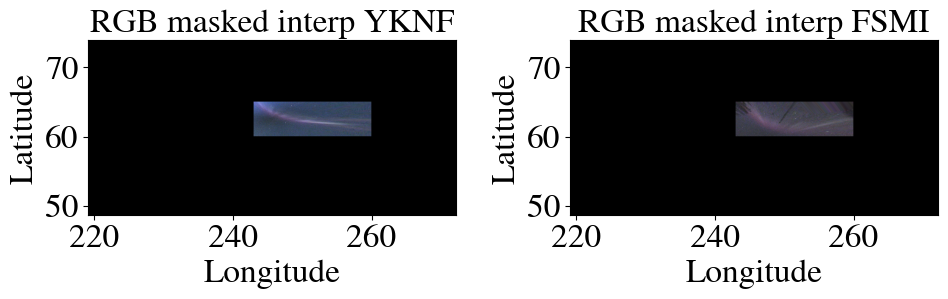

In [13]:
yknf_patch = yknf_rgb_image[box_mask, :]
fsmi_patch = fsmi_rgb_image[box_mask, :]

yknf_masked_rgb = np.zeros_like(yknf_rgb_image) 
fsmi_masked_rgb = np.zeros_like(fsmi_rgb_image) 

yknf_masked_rgb[box_mask, :] = yknf_rgb_image[box_mask, :]
fsmi_masked_rgb[box_mask, :] = fsmi_rgb_image[box_mask, :]

fig, axes = plt.subplots(1, 2, figsize=(10,20))
all_images = [yknf_masked_rgb, fsmi_masked_rgb]
all_titles = ['RGB masked interp YKNF', 'RGB masked interp FSMI']

for ax, img, title in zip(axes.flat, all_images, all_titles):
    ax.imshow(np.clip(img, 0, 1),
             origin='lower',
             extent=[lon_min, lon_max, lat_min, lat_max]) 
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()


### Looping over different altitudes

In [34]:
## Get the interpolated R, G, B channels and RGB figures 

R_corr_arr = {}
G_corr_arr = {}
B_corr_arr = {}

yknf_R_interp_arr = []
yknf_G_interp_arr = []
yknf_B_interp_arr = []

fsmi_R_interp_arr = []
fsmi_G_interp_arr = []
fsmi_B_interp_arr = []

yknf_RGB_interp_arr = []
fsmi_RGB_interp_arr = []

RGB_interp_figures = []

lat_lon_min_max_arr = [] 


## Get the projected latitude and longitude 
h_target_arr = [100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 200000, 210000, 220000, 230000, 240000, 250000, 260000]
#h_target_arr = [240000, 250000, 260000, 270000, 280000, 290000, 300000]
full_yknf_lat110 = np.array(yknf_rgb_asi_ds.lat_110)
full_yknf_lon110 = np.array(yknf_rgb_asi_ds.lon_110)
yknf_110_mask = np.isnan(full_yknf_lat110) | np.isnan(full_yknf_lon110) # apply this mask to all frames across all elevations for YKNF

lat_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

full_fsmi_lat110 = np.array(fsmi_rgb_asi_ds.lat_110)
full_fsmi_lon110 = np.array(fsmi_rgb_asi_ds.lon_110)
fsmi_110_mask = np.isnan(full_fsmi_lat110) | np.isnan(full_fsmi_lon110) # apply this mask to all frames across all elevations for FSMI

# num grid points for interpolation grid 
n_lat = 500
n_lon = 500

In [35]:
## loop to get all interpolated lon and lats + interpolation 
R_corr_arr.clear()
G_corr_arr.clear()
B_corr_arr.clear()

yknf_R_interp_arr.clear()
yknf_G_interp_arr.clear()
yknf_B_interp_arr.clear()

fsmi_R_interp_arr.clear()
fsmi_G_interp_arr.clear()
fsmi_B_interp_arr.clear()

yknf_RGB_interp_arr.clear()
fsmi_RGB_interp_arr.clear()

lat_lon_min_max_arr.clear()

for h_target in h_target_arr: 
    yknf_lat_proj, yknf_lon_proj = project_lat_lon(full_azimuth_yknf, 
                                                     full_elevation_yknf, 
                                                     lat_yknf, 
                                                     lon_yknf, 
                                                     h_target, 
                                                     yknf_110_mask)
    
    fsmi_lat_proj, fsmi_lon_proj = project_lat_lon(full_azimuth_fsmi, 
                                                     full_elevation_fsmi, 
                                                     lat_fsmi, 
                                                     lon_fsmi, 
                                                     h_target, 
                                                     fsmi_110_mask)
            
    lat_min = min(np.nanmin(yknf_lat_proj), np.nanmin(fsmi_lat_proj))
    lon_min = min(np.nanmin(yknf_lon_proj), np.nanmin(fsmi_lon_proj))
    lat_max = max(np.nanmax(yknf_lat_proj), np.nanmax(fsmi_lat_proj))
    lon_max = max(np.nanmax(yknf_lon_proj), np.nanmax(fsmi_lon_proj))

    lat_lon_min_max_arr.append((lat_min, lat_max, lon_min, lon_max))
    
    # lon_min_plot = 200
    # lon_max_plot = 300
    # lat_min_plot = 50
    # lat_max_plot = 78

    # lon_min = 200
    # lon_max = 300
    # lat_min = 50
    # lat_max = 78

    

    # get yknf_rgb and fsmi_rgb 
    R_yknf = yknf_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
    G_yknf = yknf_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
    B_yknf = yknf_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
    R_fsmi = fsmi_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
    G_fsmi = fsmi_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
    B_fsmi = fsmi_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values      
    # contrast adjustment: alpha=contrast, beta=brightness
    alpha = 5
    beta = 5
    rgb_yknf = np.stack([R_yknf, G_yknf, B_yknf], axis=-1)  # shape: (x, y, 3)
    rgb_fsmi = np.stack([R_fsmi, G_fsmi, B_fsmi], axis=-1)  # shape: (x, y, 3)
    rgb_yknf = cv2.convertScaleAbs(rgb_yknf, alpha=alpha, beta=beta)
    rgb_fsmi = cv2.convertScaleAbs(rgb_fsmi, alpha=alpha, beta=beta)
    
    yknf_interp_intensity_R, yknf_interp_intensity_G, yknf_interp_intensity_B = rgb_interpolate(yknf_lat_110_proj, yknf_lon_110_proj, yknf_rgb, 
                                                                                                n_lat, n_lon,
                                                                                                lat_min, lat_max, lon_min, lon_max)

    yknf_R_interp_arr.append(yknf_interp_intensity_R)
    yknf_G_interp_arr.append(yknf_interp_intensity_G)
    yknf_B_interp_arr.append(yknf_interp_intensity_B)

    fsmi_interp_intensity_R, fsmi_interp_intensity_G, fsmi_interp_intensity_B = rgb_interpolate(fsmi_lat_110_proj, fsmi_lon_110_proj, fsmi_rgb, 
                                                                                                n_lat, n_lon,
                                                                                                lat_min, lat_max, lon_min, lon_max)

    fsmi_R_interp_arr.append(fsmi_interp_intensity_R)
    fsmi_G_interp_arr.append(fsmi_interp_intensity_G)
    fsmi_B_interp_arr.append(fsmi_interp_intensity_B)

    # plot the interpolated RGB values to see how to clip them (save figures for reference later)
    yknf_rgb_image = np.dstack((yknf_interp_intensity_R/255.0, yknf_interp_intensity_G/255.0, yknf_interp_intensity_B/255.0))
    fsmi_rgb_image = np.dstack((fsmi_interp_intensity_R/255.0, fsmi_interp_intensity_G/255.0, fsmi_interp_intensity_B/255.0))

    yknf_RGB_interp_arr.append(yknf_rgb_image)
    fsmi_RGB_interp_arr.append(fsmi_rgb_image)

    fig, axes = plt.subplots(1, 2, figsize=(10,20))
    all_images = [yknf_rgb_image, fsmi_rgb_image]
    all_titles = [f"{h_target/1000.0}km RGB interp YKNF", f"{h_target/1000.0}km RGB interp FSMI"]
    
    for ax, img, title in zip(axes.flat, all_images, all_titles):
        ax.imshow(np.clip(img, 0, 1),
                 origin='lower',
                 extent=[lon_min, lon_max, lat_min, lat_max]) 
        ax.set_title(title)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
    
    plt.tight_layout()
    RGB_interp_figures.append(fig)
    plt.close(fig)




#### Clipping

In [36]:
### Manual clipping 
def patch_and_correlation(lat_min_box, lat_max_box, lon_min_box, lon_max_box, 
                          yknf_interp_intensity_R, yknf_interp_intensity_G, yknf_interp_intensity_B,
                          fsmi_interp_intensity_R, fsmi_interp_intensity_G, fsmi_interp_intensity_B,
                          yknf_rgb_interp, fsmi_rgb_interp, 
                          lat_mesh, lon_mesh,
                          lon_min_plot, lon_max_plot, lat_min_plot, lat_max_plot,
                          h_target):
    # box for aurora, common across 2 cameras 
    lat_mask = (lat_mesh >= lat_min_box) & (lat_mesh <= lat_max_box)
    lon_mask = (lon_mesh >= lon_min_box) & (lon_mesh <= lon_max_box)
    box_mask = lat_mask & lon_mask
    
    # apply mask to r, g, b channels
    yknf_r_patch = yknf_interp_intensity_R[box_mask]
    fsmi_r_patch = fsmi_interp_intensity_R[box_mask]
    
    yknf_g_patch = yknf_interp_intensity_G[box_mask]
    fsmi_g_patch = fsmi_interp_intensity_G[box_mask]
    
    yknf_b_patch = yknf_interp_intensity_B[box_mask]
    fsmi_b_patch = fsmi_interp_intensity_B[box_mask]
    
    # correlation calcs
    corr_r, _ = pearsonr(yknf_r_patch.flatten(), fsmi_r_patch.flatten())
    corr_g, _ = pearsonr(yknf_g_patch.flatten(), fsmi_g_patch.flatten())
    corr_b, _ = pearsonr(yknf_b_patch.flatten(), fsmi_b_patch.flatten())
    
    print(f"r corr: {corr_r}")
    print(f"g corr: {corr_g}")
    print(f"b corr: {corr_b}")

    yknf_patch = yknf_rgb_interp[box_mask, :]
    fsmi_patch = fsmi_rgb_interp[box_mask, :]
    
    yknf_masked_rgb = np.zeros_like(yknf_rgb_interp) 
    fsmi_masked_rgb = np.zeros_like(fsmi_rgb_interp) 
    
    yknf_masked_rgb[box_mask, :] = yknf_rgb_interp[box_mask, :]
    fsmi_masked_rgb[box_mask, :] = fsmi_rgb_interp[box_mask, :]
    
    fig, axes = plt.subplots(1, 2, figsize=(10,20))
    all_images = [yknf_masked_rgb, fsmi_masked_rgb]
    all_titles = [f"{h_target / 1000.0}km interp YKNF", f"{h_target / 1000.0}km interp FSMI"]

    for ax, img, title in zip(axes.flat, all_images, all_titles):
        ax.imshow(np.clip(img, 0, 1),
                 origin='lower',
                 extent=[lon_min_plot, lon_max_plot, lat_min_plot, lat_max_plot]) 
        ax.set_title(title)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
    
    plt.tight_layout()
    plt.show()

    return corr_r, corr_g, corr_b 


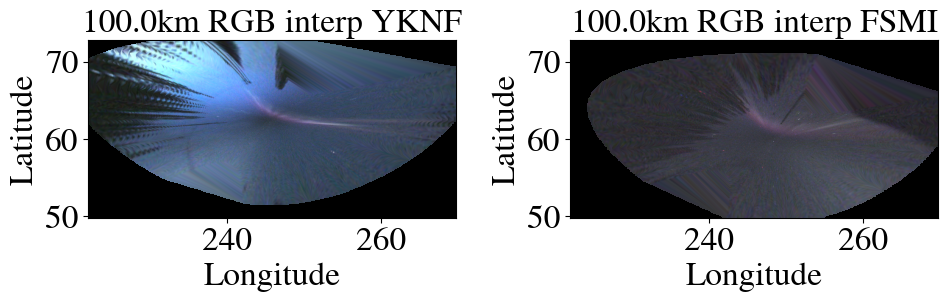

In [37]:
idx = 0
display(RGB_interp_figures[idx])


r corr: 0.16844271936965824
g corr: 0.0006251772422527085
b corr: -0.11323183008215304


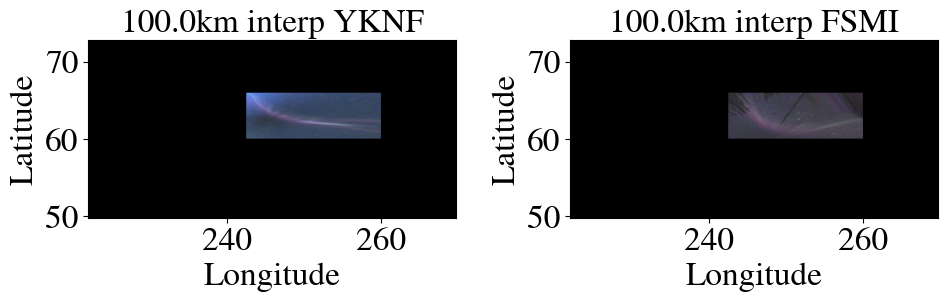

r corr: 0.16582256279258692
g corr: 0.0007193239359484377
b corr: -0.11412320355072027


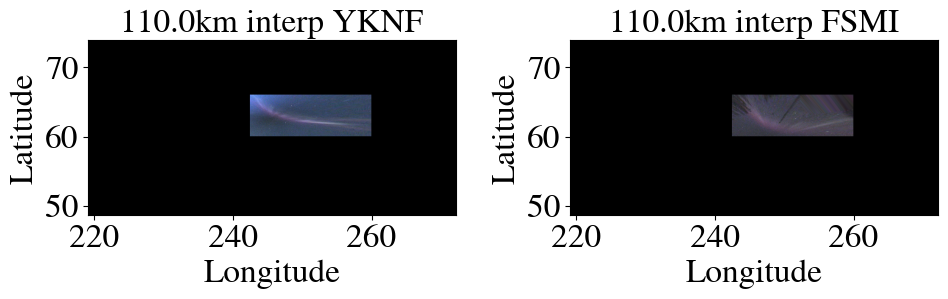

r corr: 0.1541314363241337
g corr: -0.006855058699419998
b corr: -0.11831807669342473


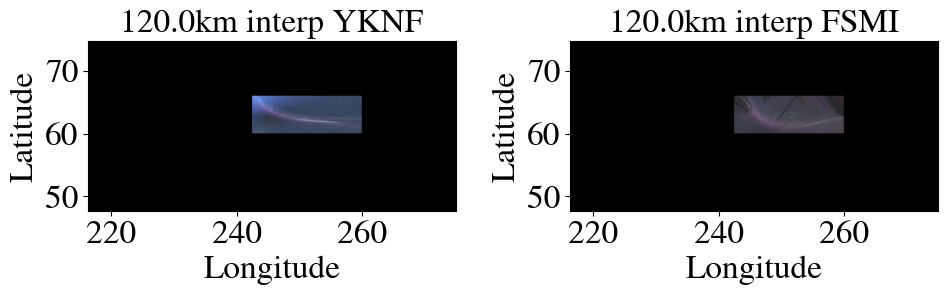

r corr: 0.1657255621211948
g corr: 0.003402377677016989
b corr: -0.10754626945487783


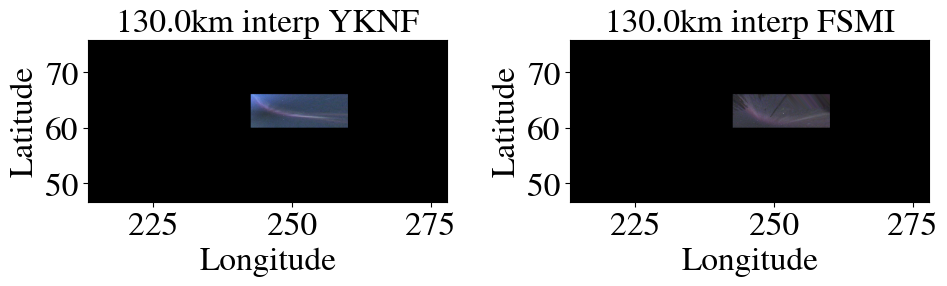

r corr: 0.17102451117708253
g corr: 0.010314397650260203
b corr: -0.10328466818690539


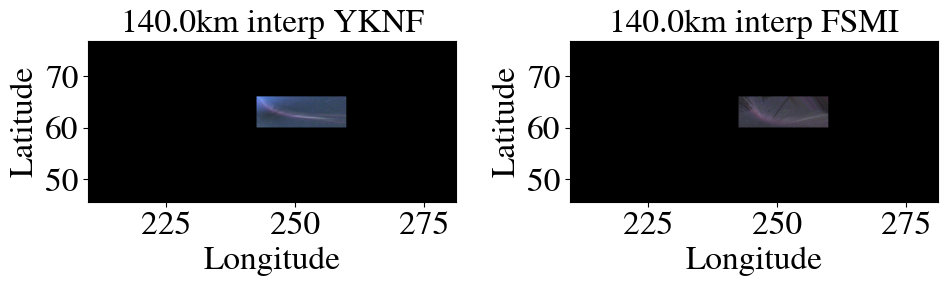

r corr: 0.1535201654861852
g corr: -0.011791874122941637
b corr: -0.12311898674261691


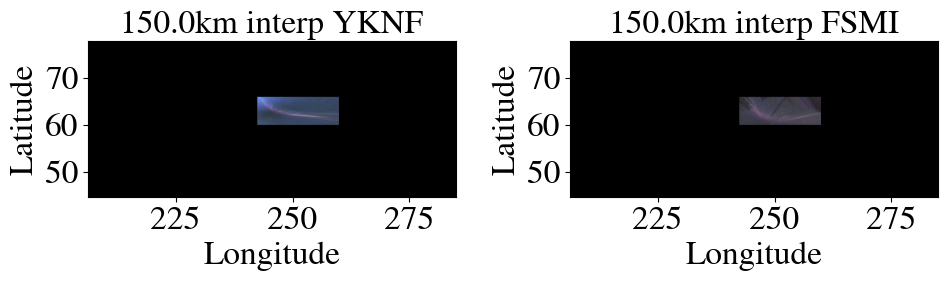

r corr: 0.15811503561514986
g corr: -0.0060631944423519615
b corr: -0.12054034092315064


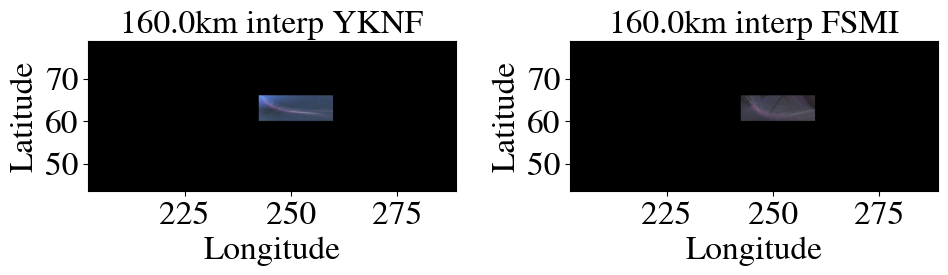

r corr: 0.16388712920978565
g corr: -0.008672265791449751
b corr: -0.12364038910940939


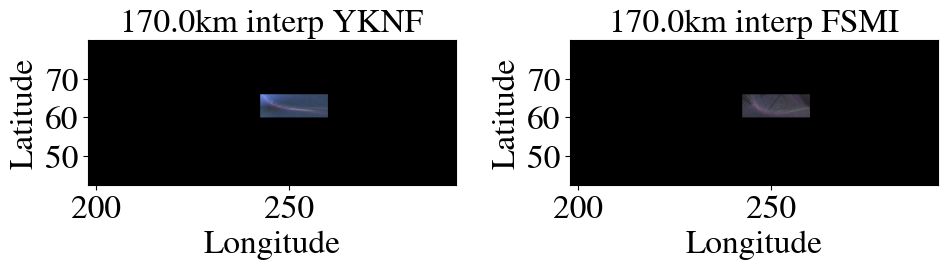

r corr: 0.16842490147722677
g corr: -0.00466738280268908
b corr: -0.10838401326969474


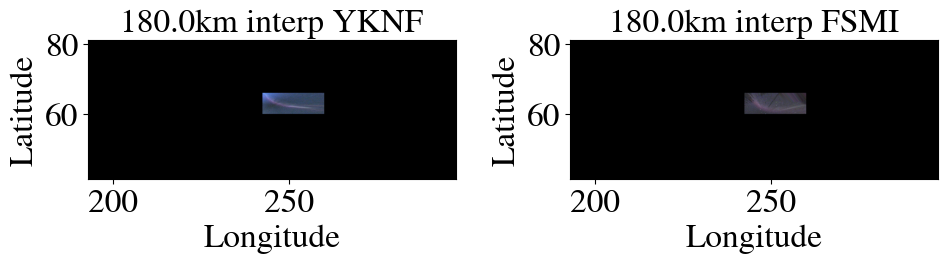

r corr: 0.17135638526934877
g corr: 0.0005226730220776951
b corr: -0.10735565739989472


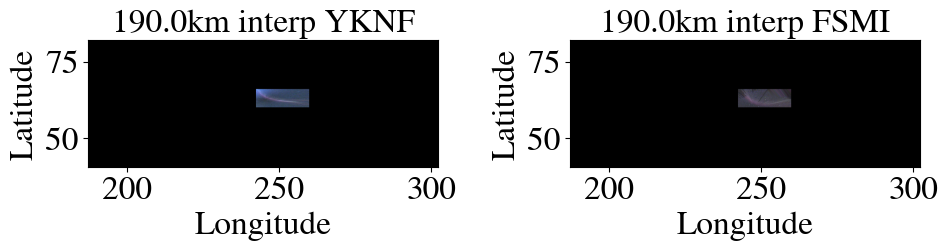

r corr: 0.16210701193422428
g corr: -0.007163261126881898
b corr: -0.12473708636906625


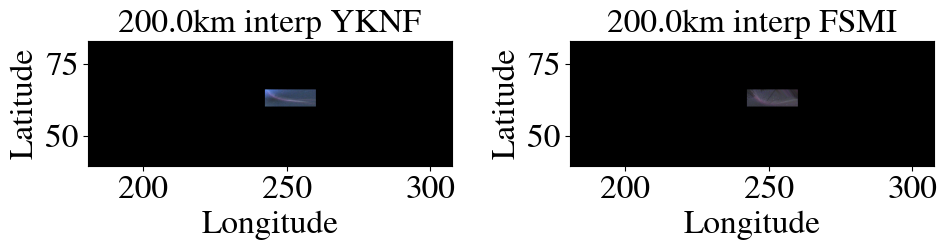

r corr: 0.164497624887359
g corr: 0.007990960864500005
b corr: -0.10379999436214611


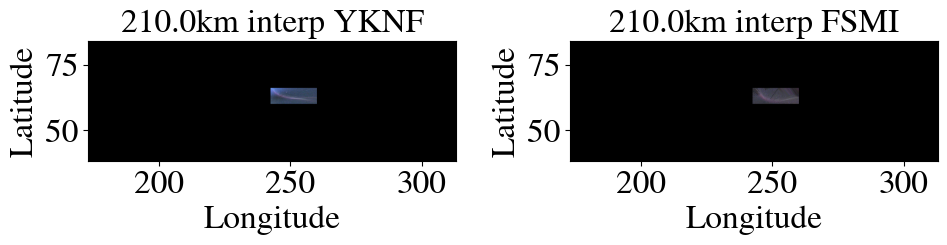

r corr: 0.16558016538109097
g corr: -0.009950425853088501
b corr: -0.11115070242970598


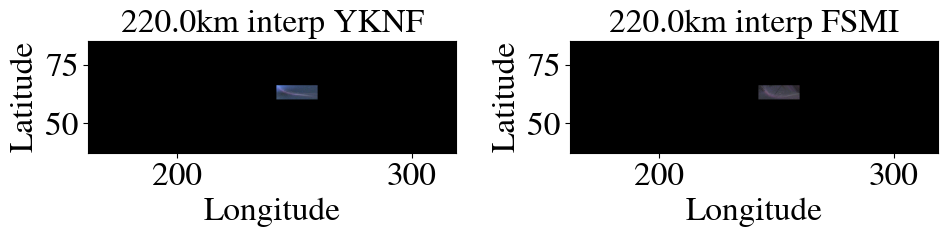

r corr: 0.1572816063924849
g corr: -0.0001281551155709968
b corr: -0.10931913847209243


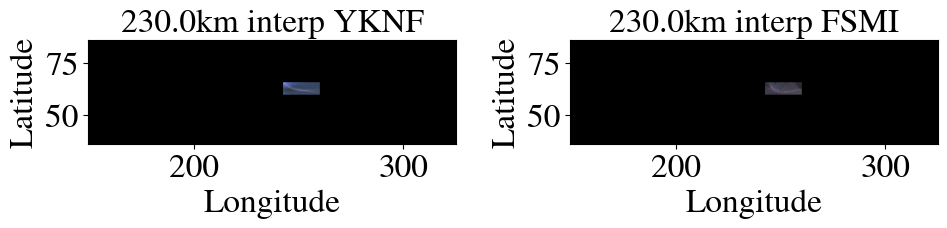

r corr: 0.1750890877859465
g corr: 0.013169555531891978
b corr: -0.10634735697889607


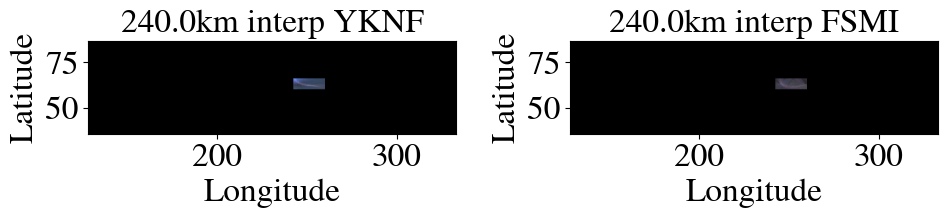

r corr: 0.16254680261871762
g corr: -0.0012631450708422837
b corr: -0.11765906355854094


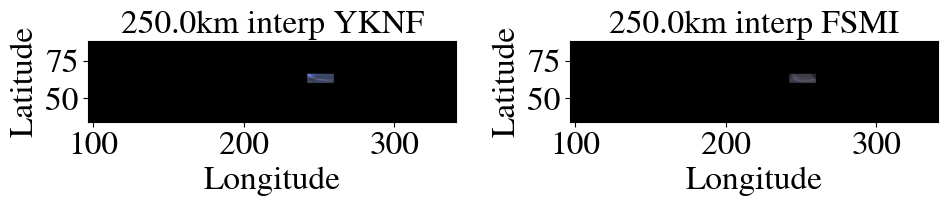

r corr: 0.14624093444053585
g corr: -0.0025606974448892476
b corr: -0.10775544554656485


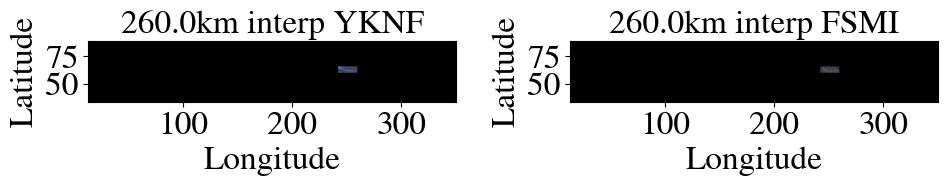

In [38]:
for idx in range(len(h_target_arr)):
    lat_min, lat_max, lon_min, lon_max = lat_lon_min_max_arr[idx]
    
    lat_grid = np.linspace(lat_min, lat_max, n_lat)
    lon_grid = np.linspace(lon_min, lon_max, n_lon)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
        
    lat_min_box = 60
    lat_max_box = 66
    lon_min_box = 242.5
    lon_max_box = 260
    
    yknf_rgb_interp = yknf_RGB_interp_arr[idx]
    fsmi_rgb_interp = fsmi_RGB_interp_arr[idx]
    
    yknf_interp_intensity_R = yknf_R_interp_arr[idx]
    yknf_interp_intensity_G = yknf_G_interp_arr[idx]
    yknf_interp_intensity_B = yknf_B_interp_arr[idx]
    
    fsmi_interp_intensity_R = fsmi_R_interp_arr[idx]
    fsmi_interp_intensity_G = fsmi_G_interp_arr[idx]
    fsmi_interp_intensity_B = fsmi_B_interp_arr[idx]

    h_target = h_target_arr[idx]
    
    r_corr, b_corr, g_corr = patch_and_correlation(lat_min_box, lat_max_box, lon_min_box, lon_max_box, 
                                                   yknf_interp_intensity_R, yknf_interp_intensity_G, yknf_interp_intensity_B,
                                                   fsmi_interp_intensity_R, fsmi_interp_intensity_G, fsmi_interp_intensity_B,
                                                   yknf_rgb_interp, fsmi_rgb_interp,
                                                   lat_mesh, lon_mesh,
                                                   lon_min, lon_max, lat_min, lat_max,
                                                   h_target
                                                  )

    R_corr_arr[h_target_arr[idx]/1000] = r_corr
    G_corr_arr[h_target_arr[idx]/1000] = g_corr
    B_corr_arr[h_target_arr[idx]/1000] = b_corr

In [ ]:
# R_corr_arr[h_target_arr[idx]/1000] = r_corr
# G_corr_arr[h_target_arr[idx]/1000] = g_corr
# B_corr_arr[h_target_arr[idx]/1000] = b_corr

In [ ]:
# R_corr_arr.clear()
# G_corr_arr.clear()
# B_corr_arr.clear()

In [42]:
R_corr_arr

{100.0: 0.16844271936965824,
 110.0: 0.16582256279258692,
 120.0: 0.1541314363241337,
 130.0: 0.1657255621211948,
 140.0: 0.17102451117708253,
 150.0: 0.1535201654861852,
 160.0: 0.15811503561514986,
 170.0: 0.16388712920978565,
 180.0: 0.16842490147722677,
 190.0: 0.17135638526934877,
 200.0: 0.16210701193422428,
 210.0: 0.164497624887359,
 220.0: 0.16558016538109097,
 230.0: 0.1572816063924849,
 240.0: 0.1750890877859465,
 250.0: 0.16254680261871762,
 260.0: 0.14624093444053585}

Text(0.5, 1.0, 'Red Channel Correlation vs Altitudes')

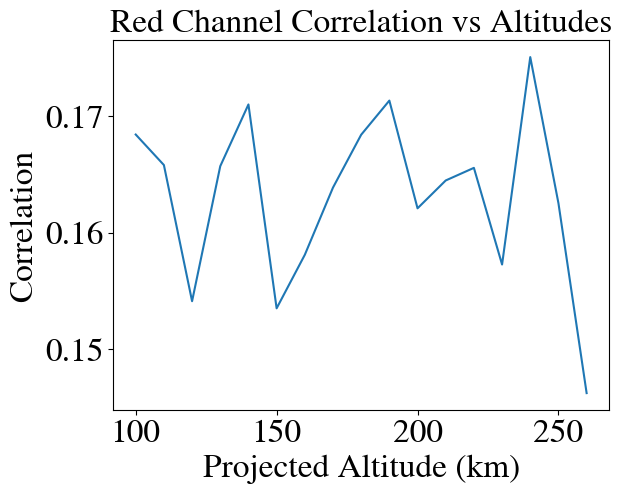

In [48]:
altitudes = list(R_corr_arr.keys())
R_corr = list(R_corr_arr.values())

plt.plot(altitudes, R_corr)
plt.xlabel("Projected Altitude (km)")
plt.ylabel("Correlation")
plt.title("Red Channel Correlation vs Altitudes")